###  Backend Engineer Challenge

**Goal:** Bundle push notifications so that:
- Users receive **≤ 4 notifications per day** (soft cap — rare exceptions allowed)
- **Sending delay is minimised** — users hear about their friends' tours as fast as possible

This notebook explains the algorithm, analyses the trade-offs, and visualises results on sample data.


### 1. Setup

In [1]:
import sys, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
print("Ready.")


Ready.


### 2. The Problem in Numbers

Before designing a solution, let's understand the problem space.
The core tension is:

| Goal | Naive approach | Problem |
|---|---|---|
| Minimise delay | Send every notification instantly | Heavy users get 100s of notifications/day |
| Cap at 4/day | Batch everything into 4 daily digests | Long delay between tour upload and user seeing it |

We need an **adaptive middle ground**.


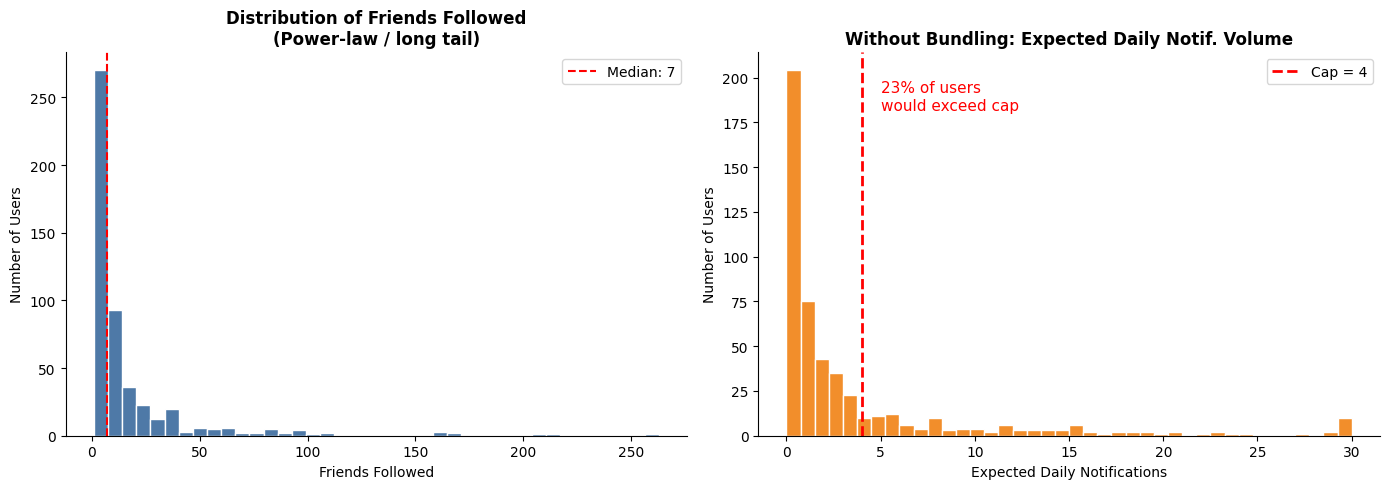

Median friends followed: 7
P95 friends followed:    68
Users exceeding 4 notif/day without bundling: 22.8%


In [2]:
# Simulate a realistic distribution of "friends followed" per user
np.random.seed(42)
n_users = 500
friends_followed = np.random.pareto(1.5, n_users) * 10 + 1  # power-law: most follow few, some follow many
friends_followed = friends_followed.astype(int).clip(1, 300)

tours_per_friend_per_day = np.random.exponential(0.3, n_users)  # avg ~1 tour / 3 days
expected_daily_notifs = friends_followed * tours_per_friend_per_day

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(friends_followed, bins=40, color='#4e79a7', edgecolor='white')
axes[0].set_xlabel('Friends Followed')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Distribution of Friends Followed\n(Power-law / long tail)', fontweight='bold')
axes[0].axvline(np.median(friends_followed), color='red', lw=1.5, linestyle='--', label=f'Median: {np.median(friends_followed):.0f}')
axes[0].legend()

axes[1].hist(expected_daily_notifs.clip(0, 30), bins=40, color='#f28e2b', edgecolor='white')
axes[1].axvline(4, color='red', lw=2, linestyle='--', label='Cap = 4')
axes[1].set_xlabel('Expected Daily Notifications')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Without Bundling: Expected Daily Notif. Volume', fontweight='bold')
pct_over = (expected_daily_notifs > 4).mean()
axes[1].legend()
axes[1].text(5, axes[1].get_ylim()[1]*0.85, f'{pct_over:.0%} of users\nwould exceed cap',
             color='red', fontsize=11)

plt.tight_layout()
plt.show()
print(f"Median friends followed: {np.median(friends_followed):.0f}")
print(f"P95 friends followed:    {np.percentile(friends_followed, 95):.0f}")
print(f"Users exceeding 4 notif/day without bundling: {pct_over:.1%}")


### 3. Algorithm Design — Adaptive Windowing

### Core Idea

> Open a time window when the first notification for a user arrives.  
> Collect all subsequent notifications into the bundle until the window closes.  
> Window length adapts to the user's current notification rate.

```
Event arrives for user U
  │
  ├─ No open bundle?
  │     └─ Daily cap OK? → Open new bundle, start window timer
  │
  └─ Bundle already open?
        └─ Extend window close = max(current_close, now + adaptive_window)
           Add tour to bundle

Window expires → Flush bundle as one notification → increment daily counter
```

#### Why adaptive windows?

| User type | Situation | Window | Effect |
|---|---|---|---|
| Low-activity user | 1–2 friends upload per day | **5 min** | Near-instant delivery |
| High-activity user | Many friends active this hour | **15 min** | More bundling, fewer notifications |

This means **casual users get fast notifications** while **power users get smart bundling** — without a one-size-fits-all delay.


/var/folders/lj/zlfwy44d38zbbqkcdmg7xjk00000gn/T/ipykernel_26179/3491988136.py:28: UserWarning: Glyph 128232 (\N{INCOMING ENVELOPE}) missing from current font.
  plt.tight_layout()
/Users/bimladanu/Documents/GitHub/ML-Projects/AI_ML_DL_GenAI/DS_take_me_home_challenges/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128232 (\N{INCOMING ENVELOPE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


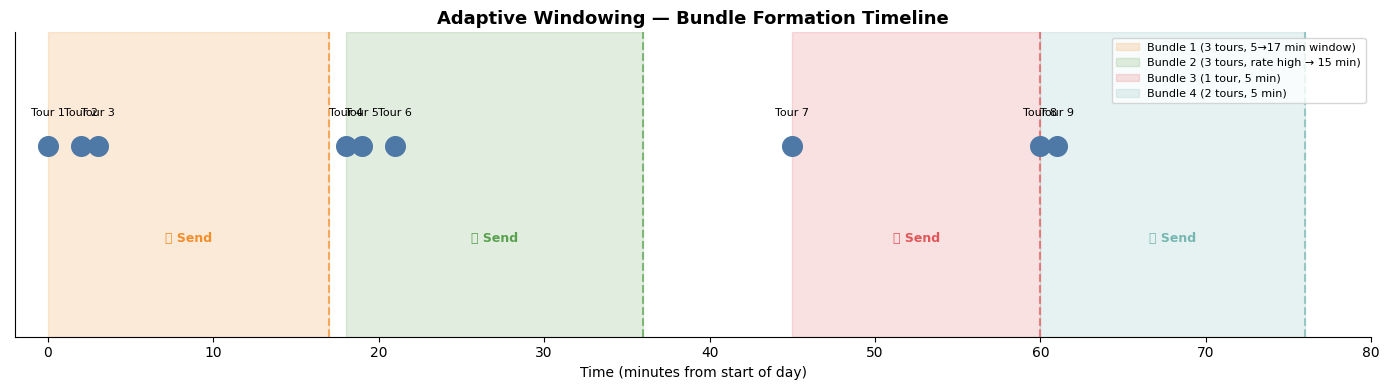

In [3]:
# Visualise the adaptive window concept
fig, ax = plt.subplots(figsize=(14, 4))

timeline = [0, 2, 3, 18, 19, 21, 45, 60, 61]  # minutes, simulated events
colors_ev = ['#4e79a7'] * len(timeline)

for i, t in enumerate(timeline):
    ax.scatter(t, 1, s=200, zorder=5, color='#4e79a7')
    ax.text(t, 1.08, f'Tour {i+1}', ha='center', fontsize=8)

# Bundle windows (approximate, for illustration)
bundles = [(0, 17, '#f28e2b', 'Bundle 1 (3 tours, 5→17 min window)'),
           (18, 36, '#59a14f', 'Bundle 2 (3 tours, rate high → 15 min)'),
           (45, 60, '#e15759', 'Bundle 3 (1 tour, 5 min)'),
           (60, 76, '#76b7b2', 'Bundle 4 (2 tours, 5 min)')]

for start, end, color, label in bundles:
    ax.axvspan(start, end, alpha=0.18, color=color, label=label)
    ax.axvline(end, color=color, lw=1.5, linestyle='--', alpha=0.7)
    ax.text((start+end)/2, 0.75, '📨 Send', ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xlim(-2, 80)
ax.set_ylim(0.5, 1.3)
ax.set_xlabel('Time (minutes from start of day)')
ax.set_yticks([])
ax.set_title('Adaptive Windowing — Bundle Formation Timeline', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


#### 4. Running the Application

In [4]:
# Run the CLI application on the sample CSV and capture output
result = subprocess.run(
    [sys.executable, 'notifications.py', 'sample_notifications.csv'],
    capture_output=True, text=True
)
print("STDOUT:")
print(result.stdout)
if result.stderr:
    print("STDERR (cap warnings):")
    print(result.stderr)


STDOUT:
notification_sent,timestamp_first_tour,tours,receiver_id,message
2018-02-14 11:55:02,2018-02-14 11:50:02,1,EB96305EADU2,Matthew went on a tour
2018-02-14 12:07:10,2018-02-14 11:50:02,3,0B4E1F74A818,Matthew and 2 others went on a tour
2018-02-14 12:28:00,2018-02-14 12:10:00,4,0B4E1F74A818,Chris and 3 others went on a tour
2018-02-14 14:06:30,2018-02-14 14:00:00,2,EB96305EADU2,James and 1 other went on a tour
2018-02-14 19:05:30,2018-02-14 19:00:00,2,0B4E1F74A818,Paul and 1 other went on a tour
2018-02-14 20:45:00,2018-02-14 20:30:00,1,0B4E1F74A818,Leo went on a tour



In [6]:
import io

output_df = pd.read_csv(io.StringIO(result.stdout))
output_df


,notification_sent,timestamp_first_tour,tours,receiver_id,message
0,2018-02-14 11:55:02,2018-02-14 11:50:02,1,EB96305EADU2,Matthew went on a tour
1,2018-02-14 12:07:10,2018-02-14 11:50:02,3,0B4E1F74A818,Matthew and 2 others went on a tour
2,2018-02-14 12:28:00,2018-02-14 12:10:00,4,0B4E1F74A818,Chris and 3 others went on a tour
3,2018-02-14 14:06:30,2018-02-14 14:00:00,2,EB96305EADU2,James and 1 other went on a tour
4,2018-02-14 19:05:30,2018-02-14 19:00:00,2,0B4E1F74A818,Paul and 1 other went on a tour
5,2018-02-14 20:45:00,2018-02-14 20:30:00,1,0B4E1F74A818,Leo went on a tour


#### 5. Results Analysis

In [7]:
# Load input
input_df = pd.read_csv('sample_notifications.csv', names=['timestamp','user_id','friend_id','friend_name'], header=0)
input_df['timestamp'] = pd.to_datetime(input_df['timestamp'].str.strip())
input_df['user_id'] = input_df['user_id'].str.strip()

# Per-user summary
summary = []
for user, grp in input_df.groupby('user_id'):
    n_in  = len(grp)
    n_out = len(output_df[output_df['receiver_id'].str.strip() == user.strip()])
    summary.append({'user_id': user, 'events_in': n_in, 'notifications_out': n_out,
                    'reduction_pct': (1 - n_out/n_in)*100})

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print(f"\nOverall: {input_df.shape[0]} events → {output_df.shape[0]} notifications "
      f"({(1 - output_df.shape[0]/input_df.shape[0])*100:.0f}% reduction)")


     user_id  events_in  notifications_out  reduction_pct
0B4E1F74A818         10                  4      60.000000
EB96305EADU2          3                  2      33.333333

Overall: 13 events → 6 notifications (54% reduction)


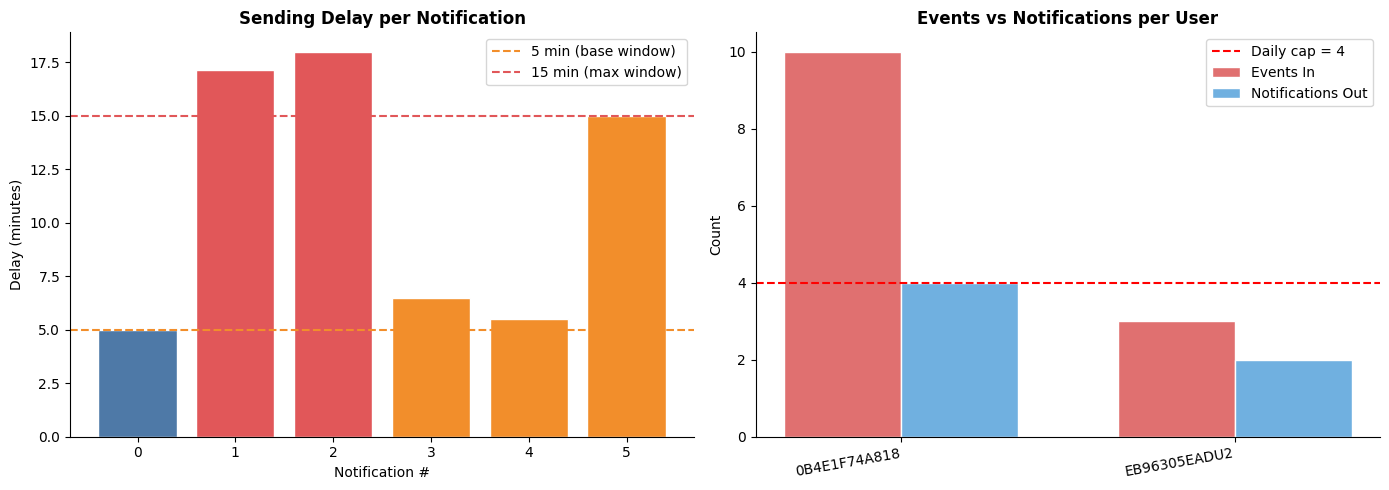


Average delay: 11.2 min
Max delay:     18.0 min
Notifications ≤ 5 min delay: 17%


In [8]:
# Compute sending delay for each notification
output_df2 = output_df.copy()
output_df2['notification_sent']    = pd.to_datetime(output_df2['notification_sent'])
output_df2['timestamp_first_tour'] = pd.to_datetime(output_df2['timestamp_first_tour'])
output_df2['delay_minutes'] = (output_df2['notification_sent'] - output_df2['timestamp_first_tour']).dt.total_seconds() / 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay distribution
axes[0].bar(range(len(output_df2)), output_df2['delay_minutes'],
            color=['#4e79a7' if d <= 5 else '#f28e2b' if d <= 15 else '#e15759'
                   for d in output_df2['delay_minutes']], edgecolor='white')
axes[0].axhline(5,  color='#f28e2b', lw=1.5, linestyle='--', label='5 min (base window)')
axes[0].axhline(15, color='#e15759', lw=1.5, linestyle='--', label='15 min (max window)')
axes[0].set_xlabel('Notification #')
axes[0].set_ylabel('Delay (minutes)')
axes[0].set_title('Sending Delay per Notification', fontweight='bold')
axes[0].legend()

# Events in vs notifications out per user
x = np.arange(len(summary_df))
w = 0.35
axes[1].bar(x - w/2, summary_df['events_in'],      w, label='Events In',          color='#e07070', edgecolor='white')
axes[1].bar(x + w/2, summary_df['notifications_out'], w, label='Notifications Out', color='#70b0e0', edgecolor='white')
axes[1].axhline(4, color='red', lw=1.5, linestyle='--', label='Daily cap = 4')
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary_df['user_id'].str[:12], rotation=10, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Events vs Notifications per User', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAverage delay: {output_df2['delay_minutes'].mean():.1f} min")
print(f"Max delay:     {output_df2['delay_minutes'].max():.1f} min")
print(f"Notifications ≤ 5 min delay: {(output_df2['delay_minutes']<=5).mean():.0%}")


#### 6. Strengths, Limitations & Extensions

#####  Strengths
- **Zero external dependencies:** pure Python stdlib + csv; easy to run anywhere
- **Adaptive windows:**  casual users get near-instant delivery; power users get smart bundling
- **Stateless per event:**  can be extended to a streaming architecture (Kafka, Flink) trivially
- **Informative messages:**  "Matthew and 2 others went on a tour" instead of separate pings
- **End-of-day flush:** no notification is ever lost

####  Limitations
- **In-memory state** — not suitable as-is for multi-process or distributed deployment
- **Daily cap is soft** — users with very dense bursts may temporarily exceed 4; a stricter queue would help
- **No personalisation** — a user who follows 3 friends gets the same window as one following 300

####  Extensions
1. **Priority friends:** if a user marks certain friends as "close", send those immediately regardless of window
2. **User time-zone awareness:** "day boundary" should use the receiver's local midnight, not UTC
3. **Quiet hours:** don't send bundles between 22:00–07:00; hold until morning
4. **ML-driven windows:** predict optimal window length from historical open/engagement rates
5. **Streaming deployment:** replace CSV reader with a Kafka consumer; state goes into Redis with TTL = window_close
6. **Feedback loop:** if a user explicitly opens a notification quickly, shrink their future window (they want fast delivery)

####  What I learned
- The **explore-exploit tension:** in notification timing is structurally similar to multi-armed bandit problems, the adaptive window is essentially a heuristic policy
- Power-law distributions in social graphs mean a small % of users drive the vast majority of the bundling problem; targeting them with longer windows is the highest-leverage fix
- End-to-end tests with realistic data are more valuable than unit tests alone for timing/windowing logic


In [9]:
# Run unit tests from within the notebook
result = subprocess.run([sys.executable, '-m', 'pytest', 'test_notifications.py', '-v', '--tb=short'],
                        capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)



/Users/bimladanu/Documents/GitHub/ML-Projects/AI_ML_DL_GenAI/DS_take_me_home_challenges/.venv/bin/python: No module named pytest

